Prepation 

In [1]:
#install all necessary libraries
%pip install beautifulsoup4 requests pandas selenium networkx matplotlib seaborn google-search-results -q google-colab-selenium webdriver-manager

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


BeautifulSoup

In [2]:
from bs4 import BeautifulSoup #to use beautiful soup
import requests
URL = "https://www.ebay.com/n/all-categories"

r = requests.get(URL)
# print(r)#200
soup = BeautifulSoup(r.content, 'html5lib')
electronics = soup.find("div", class_="cat-container",id="electronics")

all_name=[]
all_link=[]
if electronics:
  elec_category = electronics.find_all("a")
  for category in elec_category:
    name= category.text.strip()
    link= category.get("href")
    if name:
      all_name.append(name)
      all_link.append(link)
      print(f"Category: {name}")
      print(f"Link: {link}\n")
    else:
      print("No Electronicse found\n")

Category: Electronics
Link: https://www.ebay.com/b/Electronics/bn_7000259124

Category: Computers/Tablets & Networking
Link: https://www.ebay.com/b/Computers-Tablets-Network-Hardware/58058/bn_1865247

No Electronicse found

Category: Laptops & Netbooks - Computers/Tablets & Networking
Link: https://www.ebay.com/b/Laptops-Netbooks/175672/bn_1648276

Category: Computer Components & Parts - Computers/Tablets & Networking
Link: https://www.ebay.com/b/Computer-Components-Parts/175673/bn_1643095

Category: Desktops & All-In-One Computers - Computers/Tablets & Networking
Link: https://www.ebay.com/b/Desktops-All-In-One-Computers/171957/bn_1643067

Category: Tablets & eReaders - Computers/Tablets & Networking
Link: https://www.ebay.com/b/Tablets-eReaders/171485/bn_320042

Category: Computer Drives, Storage & Blank Media - Computers/Tablets & Networking
Link: https://www.ebay.com/b/Computer-Drives-Storage-Blank-Media/165/bn_738891

Category: Computer Monitors, Projectors & Accessories - Compute

Save to CSV

In [3]:
import pandas as pd
df=pd.DataFrame({"all_name":all_name,"URL":all_link})
df['Category'] = df['all_name'].str.strip()
df['URL'] = df['URL'].str.strip()
df.head(19).to_csv('ebay_categories.csv', index=False, encoding='utf-8')

print("Data saved to 'ebay_categories.csv'. Here is the preview:")
print(df[['Category', 'URL']].head(10). to_string(index=True, justify="left"))

Data saved to 'ebay_categories.csv'. Here is the preview:
  Category                                                                      URL                                                                               
0                                                                   Electronics                                   https://www.ebay.com/b/Electronics/bn_7000259124
1                                                Computers/Tablets & Networking         https://www.ebay.com/b/Computers-Tablets-Network-Hardware/58058/bn_1865247
2                           Laptops & Netbooks - Computers/Tablets & Networking                          https://www.ebay.com/b/Laptops-Netbooks/175672/bn_1648276
3                  Computer Components & Parts - Computers/Tablets & Networking                 https://www.ebay.com/b/Computer-Components-Parts/175673/bn_1643095
4              Desktops & All-In-One Computers - Computers/Tablets & Networking             https://www.ebay.com/b/Desktops-All

In [4]:
from serpapi import GoogleSearch
params={
  "engine": "amazon",
  "k":"electronics",
  "api_key": "72147cabff91cd32888f1037c43915180cbb95f2712dd79d660a83a1566d610e"
}

search = GoogleSearch(params)
result = search.get_dict()
organic_results=result['organic_results']
product_titles = []
product_links = []
product_prices = []

for product in organic_results:
    prod_title = product.get("title")
    prod_link  = product.get("link")
    prod_price = product.get("price")

    if prod_title and prod_link and prod_price:
        product_titles.append(prod_title)
        product_links.append(prod_link)
        product_prices.append(prod_price)
        
       

In [5]:
df=pd.DataFrame({"Title":product_titles,"Link":product_links,"Price":product_prices})
df['Title'] = df['Title'].str.strip()
df['Link'] = df['Link'].str.strip()

df.head(19).to_csv('ebay_products.csv', index=False, encoding='utf-8')
print("Data saved to 'ebay_products.csv'. Here is the preview:")
print(df[['Title', 'Link','Price']].head(10).to_string(index=True, justify="left"))

Data saved to 'ebay_products.csv'. Here is the preview:
  Title                                                                                                                                                                                                 Link                                                                                                                                                Price     
0       Ray-Ban Meta (Gen 2), Wayfarer, Matte Black | Smart AI Glasses for Men, Women — 2X Battery Life — 3K HD Resolution — 12 MP Ultra-Wide Camera, Audio, Video — Polarized Gradient Graphite Lenses               https://www.amazon.com/Ray-Ban-Wayfarer-Matte-Black-Smart-Glasses/dp/B0FLYDWQDZ/ref=sr_1_1?keywords=electronics&qid=1778530829&sr=8-1    $409.00
1             DJI Mini 5 Pro Fly More Combo Plus with DJI RC 2, Drone with Camera, 1-Inch CMOS, 4K Drone for Beginners, Obstacle Sensing, ActiveTrack 360°, 225° Gimbal Rotation, Extended Battery Life              https://www.a

In [7]:
import time
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager


In [8]:
chrome_options = Options()
chrome_options.add_argument("--start-maximized") # Start maximized
chrome_options.add_argument("--disable-blink-features=AutomationControlled") # Prevent detection
chrome_options.add_experimental_option("excludeSwitches", ["enable-automation"]) # Hide automation
chrome_options.add_experimental_option("useAutomationExtension", False) # Disable automation extension
chrome_options.add_argument("--user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36")
service = Service(ChromeDriverManager().install())
driver = webdriver.Chrome(service=service, options=chrome_options)
#fake id due to the figure its robot

target_url = "https://www.ebay.com/urw/Rocky-Sony-PlayStation-2-2002-/product-reviews/9355"
driver.get(target_url)
 
for step in range(1, 6):#to be slower
    driver.execute_script(f"window.scrollTo(0, {step * 900});")
    time.sleep(1.5)

review_texts   = []
review_ratings = []
review_dates   = []




try:
    wait = WebDriverWait(driver, 10)

    review_elements = driver.find_elements(By.CSS_SELECTOR,"span[class*='review-item-content'], " "p[class*='review-item-content'], " "div.ebay-review-section span" )
    rating_elements = driver.find_elements(By.CSS_SELECTOR, "span.clipped")
    date_elements = driver.find_elements(  By.CSS_SELECTOR,  "span[class*='review-item-date'], "  "span.review-date" )

    for el in review_elements:
        txt = el.get_attribute("textContent").strip()
        if txt and len(txt) > 20:
            review_texts.append(txt)

    for el in rating_elements:
        label = el.get_attribute("textContent").strip()
        if "out of 5 stars" in label:           # only get actual ratings
            rating_num = label.split(" ")[0]    # get just "5.0"
            review_ratings.append(rating_num)

    for el in date_elements:
        dt = el.get_attribute("textContent").strip()
        if dt:
            review_dates.append(dt)
except :
  print("An error")

driver.quit()

max_len = max(len(review_texts), len(review_ratings), len(review_dates), 1)

def pad(lst, length, fill="N/A"):
    return lst + [fill] * (length - len(lst))  # Add "N/A" to shorter lists

review_texts   = pad(review_texts,   max_len)
review_ratings = pad(review_ratings, max_len)
review_dates   = pad(review_dates,   max_len)
print("Suggested Items :")

df_reviews = pd.DataFrame({ "Review:":  review_texts, "Rating:":  review_ratings,  "Date:":    review_dates})
df_reviews.to_csv("ebay_reviews.csv", index=False, encoding="utf-8")

if not df_reviews.empty:
    print(df_reviews.head(10).to_string(index=True, justify="left"))
else:
    print("No reviews found.")
    

Suggested Items :
  Review:                                                                                         Rating: Date:        
0  It's a really great game to play fun and like the challenges each time you beat your opponents  5.0     Aug 25, 2020
1                                                                         Verified purchase:  Yes  N/A     Apr 20, 2025
2                                                                          • Condition: pre-owned  N/A     Dec 31, 2024
3                                                                      • Sold by: videogame_attic  N/A     Jul 27, 2017
4                                                                The game works great. Thank you.  N/A     Mar 13, 2022
5                                                                         Verified purchase:  Yes  N/A     Oct 14, 2019
6                                                                          • Condition: pre-owned  N/A     Feb 23, 2022
7                     

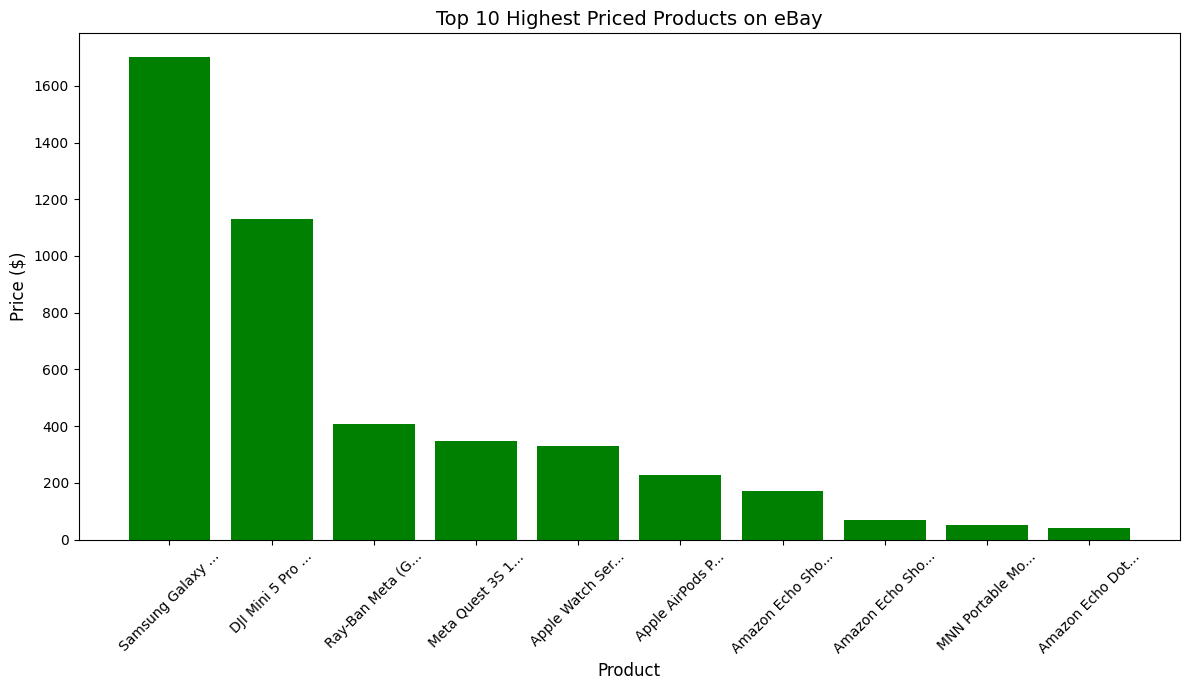

In [9]:
import matplotlib.pyplot as plt

def clean_price(price_val):
    try:
        price_str = str(price_val).replace("$","").replace(",","").strip()
        return float(price_str)
    except:
        return 0.0

df["clean_price"] = df["Price"].apply(clean_price)
top_10 = df.sort_values(by="clean_price", ascending=False).head(10)

short_titles = []
for title in top_10["Title"]:
    short_word = str(title)[:15] + "..." 
    short_titles.append(short_word)


plt.figure(figsize=(12, 7))
plt.bar(range(10), top_10["clean_price"], color="green")

plt.xticks(range(10), short_titles, rotation=45)

plt.title("Top 10 Highest Priced Products on eBay", fontsize=14)
plt.xlabel("Product", fontsize=12)
plt.ylabel("Price ($)", fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
import matplotlib.pyplot as plt
import networkx as nx

Node: 'eBay Electronics' has Degree: 10
Node: 'Ray-Ban Meta (G---' has Degree: 6
Node: 'DJI Mini 5 Pro ---' has Degree: 1
Node: 'Apple AirPods P---' has Degree: 1
Node: 'Apple Watch Ser---' has Degree: 1
Node: 'MNN Portable Mo---' has Degree: 1
Node: 'Amazon Echo Sho---' has Degree: 2
Node: 'RUNBOX Wallet f---' has Degree: 1
Node: 'RYND 2026 Trave---' has Degree: 1
Node: 'Wall Charger, S---' has Degree: 1
Node: 'WOLFBOX MegaFlo---' has Degree: 1
Node: 'Samsung Galaxy ---' has Degree: 1
Node: 'Meta Quest 3S 1---' has Degree: 1
Node: 'Amazon Echo Dot---' has Degree: 1
Node: 'Drone with Came---' has Degree: 1
Node: 'eBay Electronics' has Betweenness Centrality: 0.8352
Node: 'Ray-Ban Meta (G---' has Betweenness Centrality: 0.5055
Node: 'DJI Mini 5 Pro ---' has Betweenness Centrality: 0.0000
Node: 'Apple AirPods P---' has Betweenness Centrality: 0.0000
Node: 'Apple Watch Ser---' has Betweenness Centrality: 0.0000
Node: 'MNN Portable Mo---' has Betweenness Centrality: 0.0000
Node: 'Amazon Ec

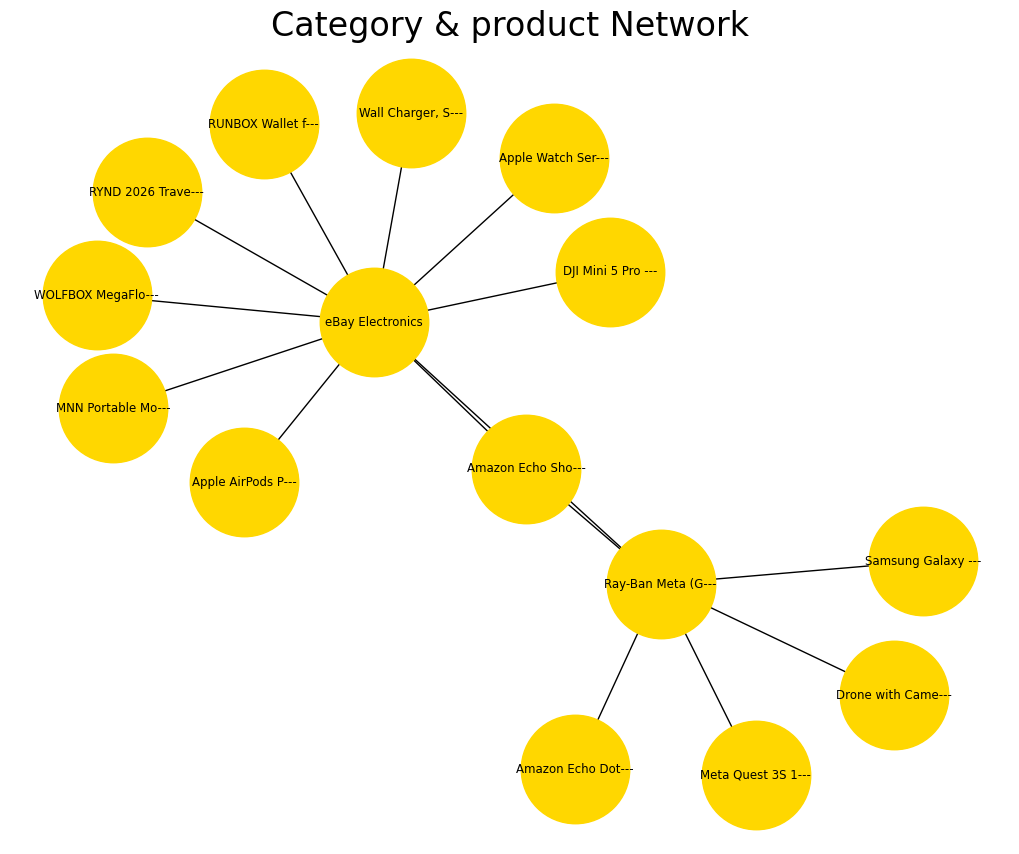

In [11]:
G= nx.Graph()
main = "eBay Electronics"
first_product = " "
G.add_node(main)
for index , row in df.head(10).iterrows():
  product_title = str(row["Title"])[:15]+"---"
  if index ==0:
    first_product = product_title
  G.add_node(product_title)
  G.add_edge(main,product_title)
  
recommendation_titles = df["Title"].tail(5).tolist()
for rec in recommendation_titles:
  rec_title = str(rec)[:15]+"---"
  G.add_node(rec_title)
  G.add_edge(first_product,rec_title)

degree = dict(G.degree())
betweenness = nx.betweenness_centrality(G)
max_degree = max(degree, key=degree.get)
max_betweenness = max(betweenness, key=betweenness.get)
for node, deg in degree.items():
    print(f"Node: '{node}' has Degree: {deg}")
for node, bet in betweenness.items():
    print(f"Node: '{node}' has Betweenness Centrality: {bet:.4f}")
    
most_connections=degree[max_degree]
#print all degree node , betwenness, max
print(f"\nKey Node Identified: '{max_degree}' with {most_connections} connections.")
print(f"Node with Highest Betweenness: '{max_betweenness}' with {betweenness[max_betweenness]:.4f}")

plt.figure(figsize=(10,8))
nx.draw(G,with_labels=True,node_color="gold",node_size=6100,font_size=8.5)
plt.title("Category & product Network",fontsize=24)
plt.show()

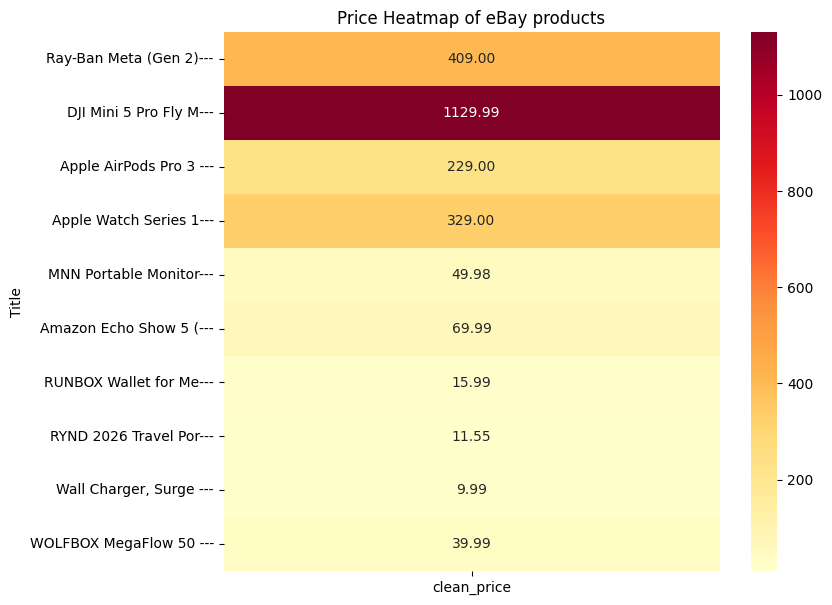

In [12]:
import seaborn as sns
def clean_price(price_val):
  try:
    if type(price_val)== dict and "extracted" in price_val:
      return float(price_val["extracted"])
    price_str=str(price_val)
    if"'extracted'" in price_str:
      right_side = price_str.split("'extracted':")[1]
      clean_number = right_side.split("}")[0].split(",")[0].strip()
      return float(clean_number)
    else:
      final_price = price_str.replace("$","").replace(",","").strip()
      return float(final_price)
  except:
    return 0.0

def text(x):
  return str(x)[:20]+"---"
heatmap = df.head(10).copy()
heatmap["clean_price"]=heatmap["Price"].apply(clean_price)
heatmap["Title"]=heatmap["Title"].apply(text)
heatmap.set_index("Title",inplace=True)
plt.figure(figsize=(8,7))
sns.heatmap(data=heatmap[["clean_price"]],annot=True,fmt=".2f",cmap="YlOrRd")
plt.title("Price Heatmap of eBay products")
plt.show()

Phase 2 

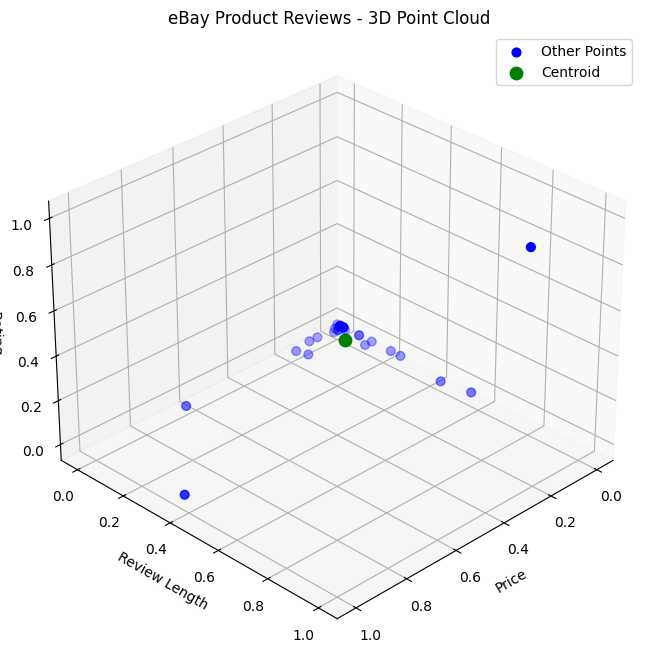

In [13]:
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt
import numpy as np

X = []  # Price
Y = []  # Review Length  
Z = []  # Rating


for i, row in df_reviews.iterrows():
    review = str(row["Review:"])
    rating = str(row["Rating:"])
    
    try:
        price = df["Price"].iloc[i]
        price_str = str(price).replace("$","").replace(",","").strip()
        price_val = float(price_str)
    except:
        price_val = 0.0

    X.append(price_val)                                       
    Y.append(len(review))                                     
    Z.append(float(rating) if rating != "N/A" else 0.0)     



def normalize(lst):
    X = np.array(lst)
    Xmin = np.min(X)
    Xmax = np.max(X)
    
    if Xmax == Xmin:
        return [0.0] * len(lst)
        
    XN = (X - Xmin) / (Xmax - Xmin)
    return XN.tolist()

X = normalize(X)
Y = normalize(Y)
Z = normalize(Z)

centroid_x = np.mean(X)
centroid_y = np.mean(Y)
centroid_z = np.mean(Z)

fig = plt.figure(figsize=(8, 12))
ax  = fig.add_subplot(projection='3d')


ax.set_xlabel('Price')
ax.set_ylabel('Review Length')
ax.set_zlabel('Rating')
ax.view_init(elev=30, azim=45)
ax.scatter(X, Y, Z, c='blue', marker='o', s=40, label='Other Points')
ax.scatter(centroid_x, centroid_y, centroid_z, c='green', marker='o', s=80, label='Centroid')
ax.legend()
plt.title("eBay Product Reviews - 3D Point Cloud")
plt.draw()
plt.show()

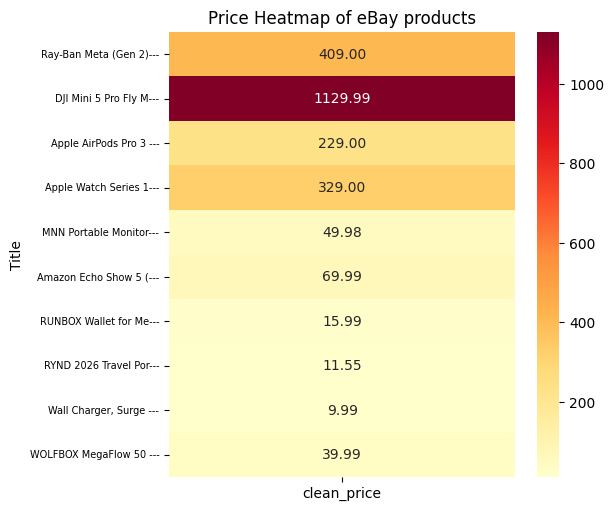

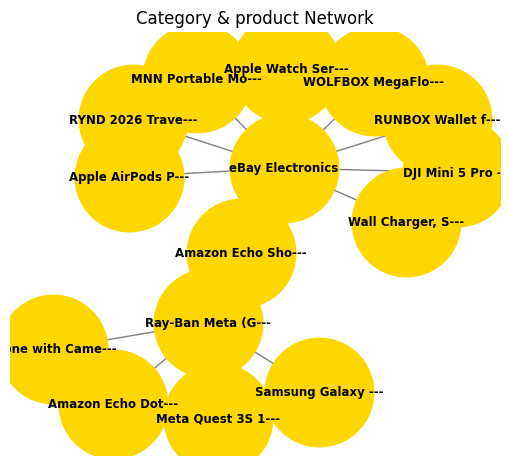

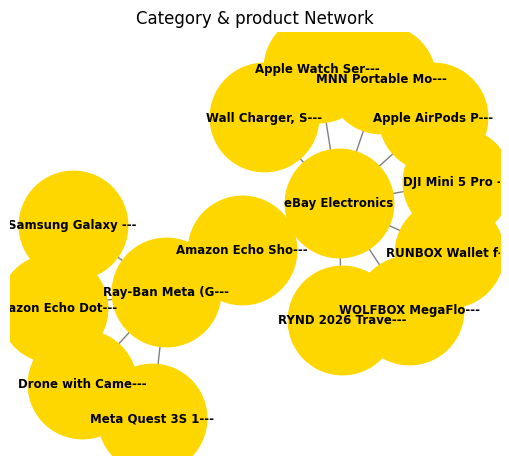

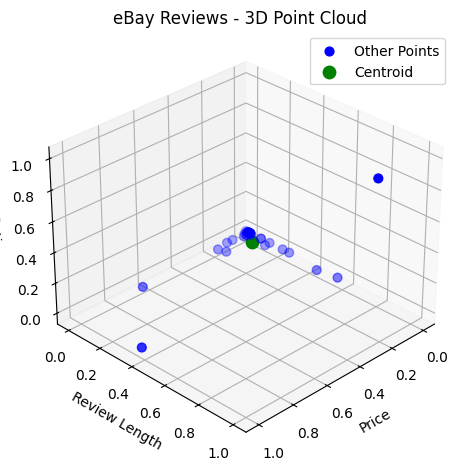

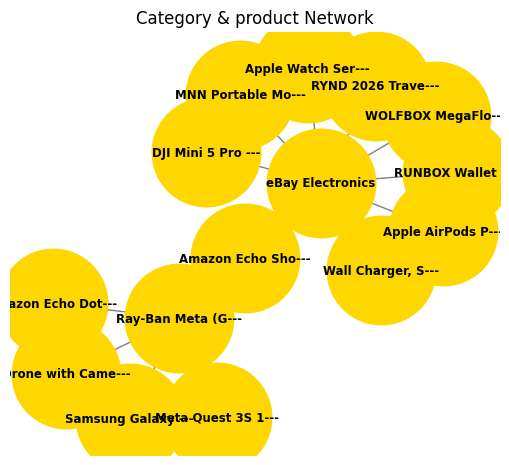

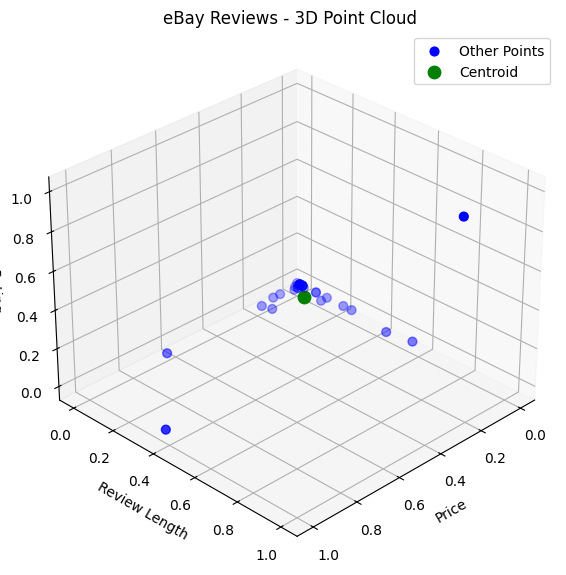

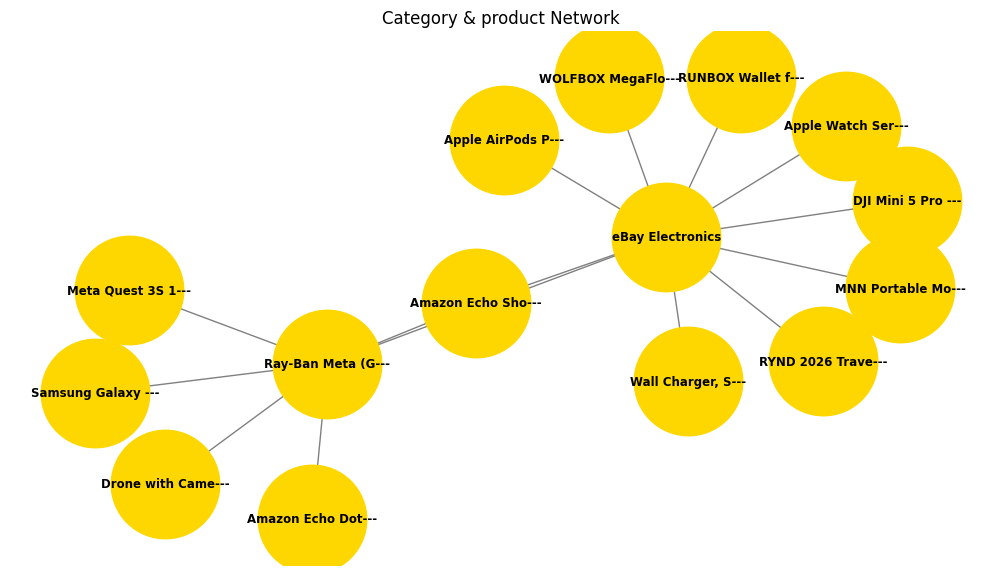

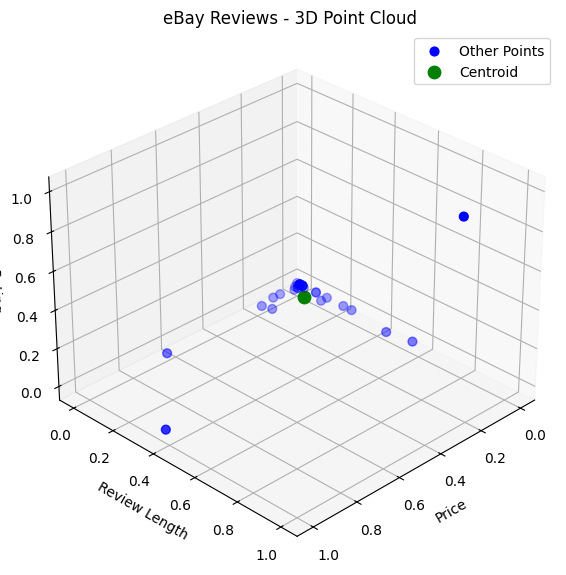

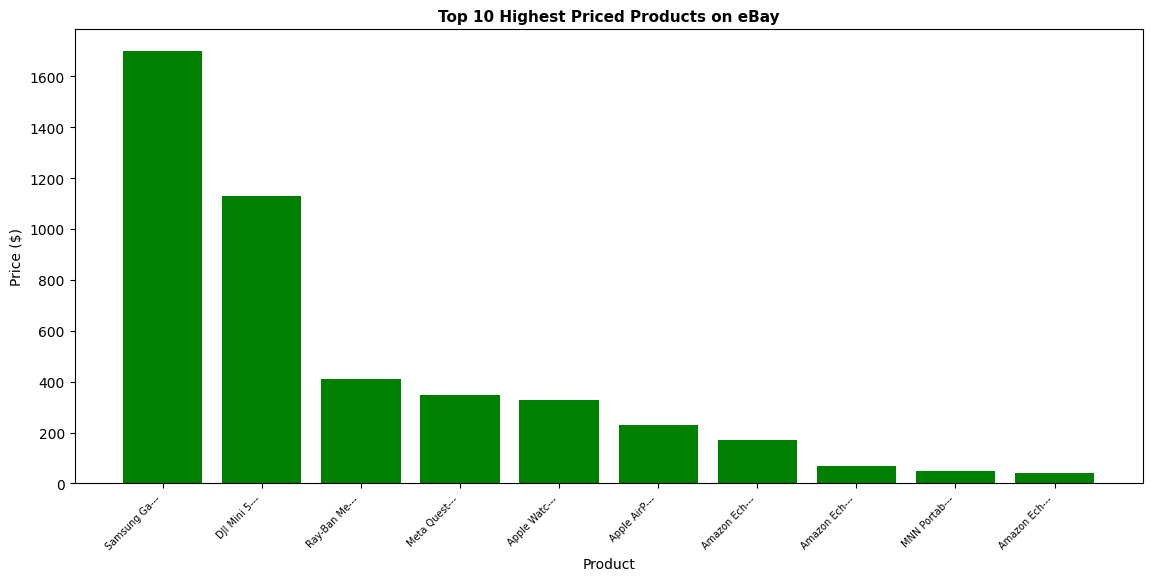

In [ ]:
import tkinter as tk
from tkinter import ttk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import matplotlib.pyplot as plt
import networkx as nx
from mpl_toolkits import mplot3d

# Main window
root = tk.Tk()
root.title("eBay Electronics Dashboard")
root.geometry("900x650")
root.configure(bg="white")

title = tk.Label(root, text="eBay Electronics Dashboard",
                 font=("Arial", 20, "bold"),
                 bg="white", fg="#333333")
title.pack(pady=10)

btn_frame = tk.Frame(root, bg="white")
btn_frame.pack(side="left", padx=20, pady=20)


plot_frame = tk.Frame(root, bg="white", relief="solid", bd=1)
plot_frame.pack(side="right", fill="both", expand=True, padx=20, pady=20)

# HELPER — clears old plot and draws new one

def show_plot(fig):
    for widget in plot_frame.winfo_children():
        widget.destroy()
    canvas = FigureCanvasTkAgg(fig, master=plot_frame)
    canvas.draw()
    canvas.get_tk_widget().pack(fill="both", expand=True)

#Button 1 — HEATMAP 
def show_heatmap():
    import seaborn as sns

    def clean_price(price_val):
        try:
            price_str = str(price_val).replace("$","").replace(",","").strip()
            return float(price_str)
        except:
            return 0.0

    def short_title(x):
        return str(x)[:20] + "---"

    heatmap_df = df.head(10).copy()
    heatmap_df["clean_price"] = heatmap_df["Price"].apply(clean_price)
    heatmap_df["Title"]       = heatmap_df["Title"].apply(short_title)
    heatmap_df.set_index("Title", inplace=True)

    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(data=heatmap_df[["clean_price"]],
                annot=True, fmt=".2f",
                cmap="YlOrRd", ax=ax,
                yticklabels=True)

    ax.yaxis.set_label_position("left")
    ax.yaxis.tick_left()
    ax.tick_params(axis='y', labelsize=7)
    ax.set_title("Price Heatmap of eBay products")
    fig.tight_layout()
    show_plot(fig)

# BUTTON 2 — NETWORKX
def show_network():
    G = nx.Graph()

    main = "eBay Electronics"
    G.add_node(main)

    first_product = " "
    for index, row in df.head(10).iterrows():
        product_title = str(row["Title"])[:15] + "---"
        if index == 0:
            first_product = product_title
        G.add_node(product_title)
        G.add_edge(main, product_title)

    recommendation_titles = df["Title"].tail(5).tolist()
    for rec in recommendation_titles:
        rec_title = str(rec)[:15] + "---"
        G.add_node(rec_title)
        G.add_edge(first_product, rec_title)

    fig, ax = plt.subplots(figsize=(6, 4))
    nx.draw(G, with_labels=True, node_color="gold",
            node_size=6100, font_size=8.5,
            font_weight="bold", edge_color="gray", ax=ax)
    ax.set_title("Category & product Network")
    show_plot(fig)


# BUTTON 3 — 3D POINT CLOUD

def show_pointcloud():
    X = []
    Y = []
    Z = []

    for i, row in df_reviews.iterrows():
        review = str(row["Review:"])
        rating = str(row["Rating:"])
        try:
            price     = df["Price"].iloc[i]
            price_str = str(price).replace("$","").replace(",","").strip()
            price_val = float(price_str)
        except:
            price_val = 0.0

        X.append(price_val)
        Y.append(len(review))
        Z.append(float(rating) if rating != "N/A" else 0.0)

    def normalize(lst):
        mn, mx = min(lst), max(lst)
        if mx == mn:
            return [0.0] * len(lst)
        return [(v - mn) / (mx - mn) for v in lst]

    X = normalize(X)
    Y = normalize(Y)
    Z = normalize(Z)

    fig = plt.figure(figsize=(6, 4))
    ax  = fig.add_subplot(projection='3d')
    
    ax.scatter(X, Y, Z, c='blue', marker='o', s=40, label='Other Points')
    ax.scatter(centroid_x, centroid_y, centroid_z, c='green', marker='o', s=80, label='Centroid')
    ax.set_xlabel('Price')
    ax.set_ylabel('Review Length')
    ax.set_zlabel('Rating')
    ax.view_init(elev=30, azim=45)
    ax.legend()
    ax.set_title("eBay Reviews - 3D Point Cloud")
    show_plot(fig)


# Button 4 — REVIEWS TABLE

def show_reviews():
    for widget in plot_frame.winfo_children():
        widget.destroy()

    product_name = "Rocky - Sony PlayStation 2 (2002)"
    header = tk.Label(plot_frame,
                      text=f"Reviews for: {product_name}",
                      font=("Arial", 13, "bold"),
                      bg="white", fg="#333333")
    header.pack(pady=8)

    cols = ["Review:", "Rating:", "Date:"]
    tree = ttk.Treeview(plot_frame, columns=cols, show="headings")

    tree.heading("Review:", text="Review")
    tree.heading("Rating:", text="Rating")
    tree.heading("Date:",   text="Date")

    tree.column("Review:", width=400)
    tree.column("Rating:", width=60)
    tree.column("Date:",   width=100)

    for _, row in df_reviews.head(20).iterrows():
        tree.insert("", "end", values=(
            str(row["Review:"])[:60],
            str(row["Rating:"]),
            str(row["Date:"])
        ))

    scrollbar = ttk.Scrollbar(plot_frame, orient="vertical", command=tree.yview)
    tree.configure(yscrollcommand=scrollbar.set)
    scrollbar.pack(side="right", fill="y")
    tree.pack(fill="both", expand=True)


# Button 5 — BAR CHART (Top 10 Highest Priced Products)

def show_barchart():
    def clean_price(price_val):
        try:
            price_str = str(price_val).replace("$","").replace(",","").strip()
            return float(price_str)
        except:
            return 0.0

    df["clean_price"] = df["Price"].apply(clean_price)
    df_sorted = df.sort_values(by="clean_price", ascending=False)
    top_10    = df_sorted.head(10)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(range(len(top_10)), top_10["clean_price"], color="green")
    ax.set_xticks(range(len(top_10)))
    ax.set_xticklabels([str(t)[:10]+"---" for t in top_10["Title"]],
                        rotation=45, ha="right", fontsize=7)
    ax.set_title("Top 10 Highest Priced Products on eBay",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Product")
    ax.set_ylabel("Price ($)")
    fig.tight_layout()
    show_plot(fig)


# BUTTONS

btn_style = {"font": ("Arial", 13, "bold"), "width": 18,
             "pady": 10, "bd": 0, "cursor": "hand2"}

tk.Button(btn_frame, text="📊  Heatmap",
          bg="#4CAF50", fg="white",
          command=show_heatmap,    **btn_style).pack(pady=10)

tk.Button(btn_frame, text="🕸️  Network",
          bg="#2196F3", fg="white",
          command=show_network,    **btn_style).pack(pady=10)

tk.Button(btn_frame, text="☁️  Point Cloud",
          bg="#9C27B0", fg="white",
          command=show_pointcloud, **btn_style).pack(pady=10)

tk.Button(btn_frame, text="📋  Reviews",
          bg="#FF5722", fg="white",
          command=show_reviews,    **btn_style).pack(pady=10)

tk.Button(btn_frame, text="📈  Bar Chart",
          bg="#FF9800", fg="white",
          command=show_barchart,   **btn_style).pack(pady=10)



root.mainloop()

Bonus 

In [ ]:
# Part 1: RECOMMENDATION SYSTEM (Complete)


import pandas as pd
from itertools import combinations
from collections import defaultdict

products = pd.read_csv("ebay_products.csv")
products = products.rename(columns={"Title": "product_name"})
products["category"] = "Video Game" 

#  Filter gaming category 
gaming_df = products[products["category"].str.lower().str.contains("game", na=False)]
gaming_df = gaming_df.dropna(subset=['product_name', 'category'])

if len(gaming_df) == 0:
    print("Uh oh! gaming_df is STILL empty. Check your CSV file.")
else:
    print(f" Success! Processing {len(gaming_df)} products for recommendations.\n")
    co_occurrence = defaultdict(int)


    for category, group in gaming_df.groupby("category"):
        product_list = list(group["product_name"])
        
        for p1, p2 in combinations(product_list, 2):
            co_occurrence[(p1, p2)] += 1
            co_occurrence[(p2, p1)] += 1


    def recommend(product_name):
        scores = {}
        for (p1, p2), count in co_occurrence.items():
            if p1 == product_name:
                scores[p2] = count
        return sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]

    
    print("--- Sample of products available ---")
    for p in gaming_df["product_name"].unique()[:3]:
        print(f"- {str(p)[:50]}...")

   
    test_product = gaming_df["product_name"].iloc[0]

    print(f"\n--- Top 5 Recommendations for: {str(test_product)[:30]}... ---")
    
    recs = recommend(test_product)
    
    if len(recs) == 0:
        print("No recommendations found for this product yet.")
    else:
        for product, score in recs:
            print(f" {str(product)[:60]}... (Co-occurrence Score: {score})")

 Success! Processing 16 products for recommendations.

--- Sample of products available ---
- Ray-Ban Meta (Gen 2), Wayfarer, Matte Black | Smar...
- DJI Mini 5 Pro Fly More Combo Plus with DJI RC 2, ...
- Apple AirPods Pro 3 Wireless Earbuds, Active Noise...

--- Top 5 Recommendations for: Ray-Ban Meta (Gen 2), Wayfarer... ---
 DJI Mini 5 Pro Fly More Combo Plus with DJI RC 2, Drone with... (Co-occurrence Score: 1)
 Apple AirPods Pro 3 Wireless Earbuds, Active Noise Cancellat... (Co-occurrence Score: 1)
 Apple Watch Series 11 [GPS 42mm] Smartwatch with Jet Black A... (Co-occurrence Score: 1)
 MNN Portable Monitor 15.6inch FHD 1080P USB C HDMI Gaming Ul... (Co-occurrence Score: 1)
 Amazon Echo Show 5 (newest model), Smart display, Designed f... (Co-occurrence Score: 1)



Communities:
Community 1 : ['Samsung Galaxy ...', 'Meta Quest 3S 1...', 'RUNBOX Wallet f...', 'RYND 2026 Trave...', 'Ray-Ban Meta (G...', 'Apple AirPods P...', 'Wall Charger, S...', 'DJI Mini 5 Pro ...', 'Apple Watch Ser...', 'WOLFBOX MegaFlo...', 'Drone with Came...', 'MNN Portable Mo...']
Community 2 : ['Amazon Echo Sho...']
Community 3 : ['Amazon Echo Dot...']


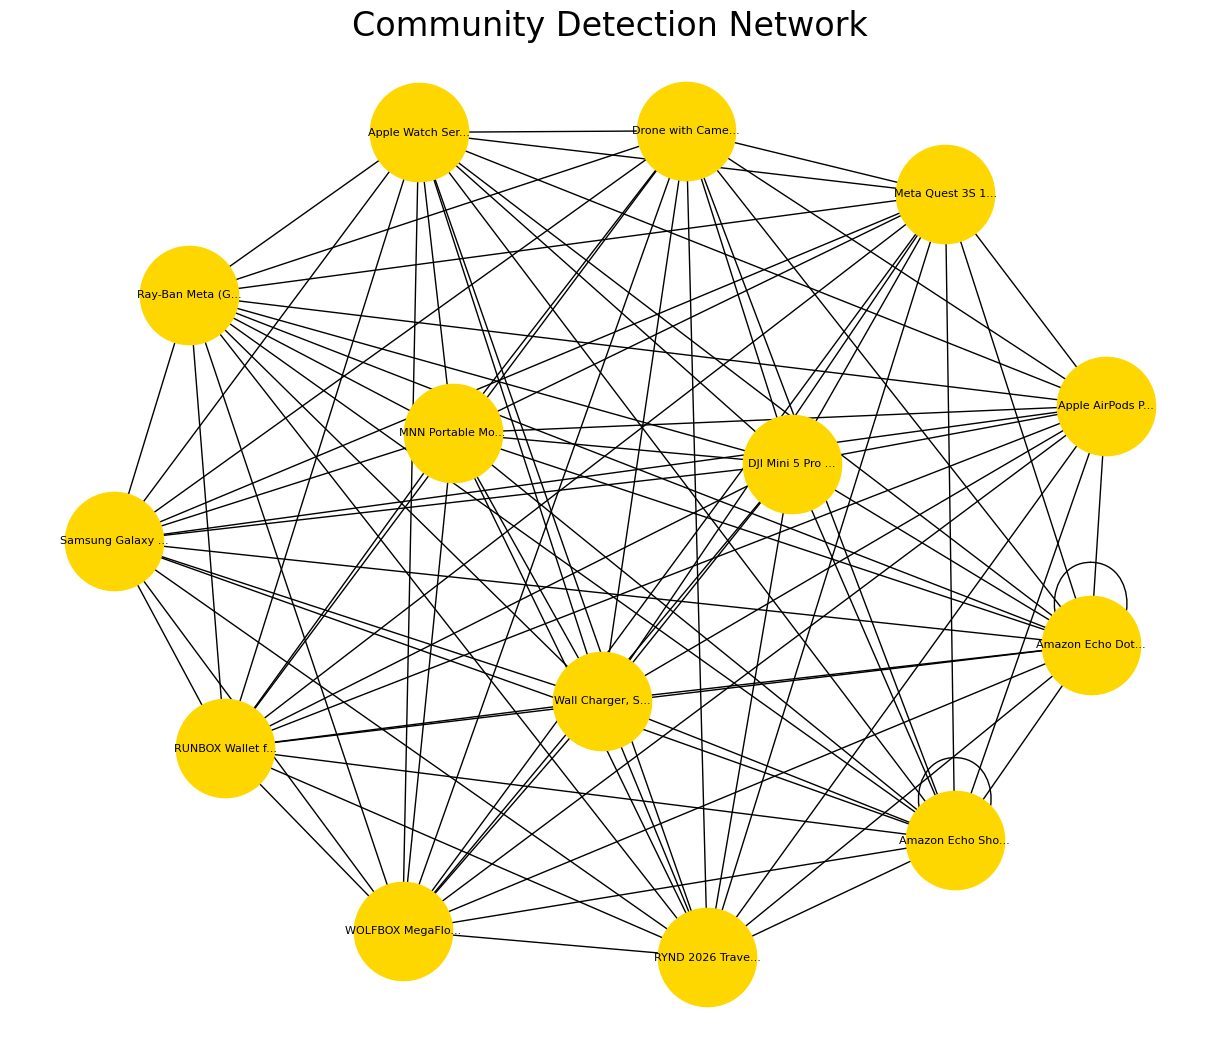

In [9]:
# PART 2: COMMUNITY DETECTION


import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms import community


G = nx.Graph()

for (p1, p2), weight in co_occurrence.items():
    if weight >= 1:  
        short_p1 = str(p1)[:15].ljust(15) + "..."
        short_p2 = str(p2)[:15].ljust(15) + "..."
        
        G.add_edge(short_p1, short_p2, weight=weight)


communities = community.greedy_modularity_communities(G)
print("\nCommunities:")
for i, comm in enumerate(communities):
    print("Community", i+1, ":", list(comm))


plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, k=0.8)
nx.draw(G, pos,with_labels=True,node_color="gold",node_size=5000, font_size=8)
plt.title("Community Detection Network", fontsize=24)
plt.show()